# CNN Development on Custom Dataset
## Tomato Disease Classification using a Custom CNN

### Objective
The goal of this project is to design, train, and evaluate a custom Convolutional Neural Network (CNN) for multi-class tomato leaf disease classification. Two models are compared:
1. A baseline custom CNN
2. A regularized CNN with Batch Normalization and Dropout

The project includes:
- data loading and preprocessing
- train/validation/test split
- custom CNN design
- training with optimizer and learning-rate scheduling
- evaluation using accuracy, precision, recall, and F1-score
- confusion matrix visualization
- per-class performance analysis
- saving trained model weights

**1. Install libraries**

In [1]:
!pip install torchinfo

**2. Import libraries**

In [2]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from torchinfo import summary

**3. Set seed and device**

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


**4. Dataset download from Kaggle**

In [ ]:
!pip install -q kaggle

from google.colab import files
files.upload()

In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d cookiefinder/tomato-disease-multiple-sources -p /content/
!unzip -q /content/tomato-disease-multiple-sources.zip -d /content/tomato_dataset

Dataset URL: https://www.kaggle.com/datasets/cookiefinder/tomato-disease-multiple-sources
License(s): CC0-1.0
100% 1.37G/1.37G [01:34<00:00, 15.5MB/s]



**5. Set dataset paths**

In [7]:
train_dir = "/content/tomato_dataset/train"
test_dir  = "/content/tomato_dataset/valid"

print("Train folders:", os.listdir(train_dir)[:10])
print("Test folders :", os.listdir(test_dir)[:10])

Train folders: ['Bacterial_spot', 'Septoria_leaf_spot', 'Early_blight', 'healthy', 'Tomato_mosaic_virus', 'powdery_mildew', 'Leaf_Mold', 'Target_Spot', 'Late_blight', 'Spider_mites Two-spotted_spider_mite']
Test folders : ['Bacterial_spot', 'Septoria_leaf_spot', 'Early_blight', 'healthy', 'Tomato_mosaic_virus', 'powdery_mildew', 'Leaf_Mold', 'Target_Spot', 'Late_blight', 'Spider_mites Two-spotted_spider_mite']


**6. Load and explore dataset**

In [8]:
train_base_dataset = datasets.ImageFolder(train_dir)
class_names = train_base_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Total images in train folder:", len(train_base_dataset))

Classes: ['Bacterial_spot', 'Early_blight', 'Late_blight', 'Leaf_Mold', 'Septoria_leaf_spot', 'Spider_mites Two-spotted_spider_mite', 'Target_Spot', 'Tomato_Yellow_Leaf_Curl_Virus', 'Tomato_mosaic_virus', 'healthy', 'powdery_mildew']
Number of classes: 11
Total images in train folder: 25851


Check class distribution:

In [9]:
class_counts = {}
for class_name in class_names:
    class_folder = os.path.join(train_dir, class_name)
    class_counts[class_name] = len([
        f for f in os.listdir(class_folder)
        if os.path.isfile(os.path.join(class_folder, f))
    ])

class_counts_df = pd.DataFrame(class_counts.items(), columns=["Class", "Count"])
class_counts_df = class_counts_df.sort_values("Count", ascending=False)
print(class_counts_df)

                                   Class  Count
2                            Late_blight   3113
9                                healthy   3051
4                     Septoria_leaf_spot   2882
0                         Bacterial_spot   2826
3                              Leaf_Mold   2754
1                           Early_blight   2455
8                    Tomato_mosaic_virus   2153
7          Tomato_Yellow_Leaf_Curl_Virus   2039
6                            Target_Spot   1827
5   Spider_mites Two-spotted_spider_mite   1747
10                        powdery_mildew   1004


Plot the class distribution:

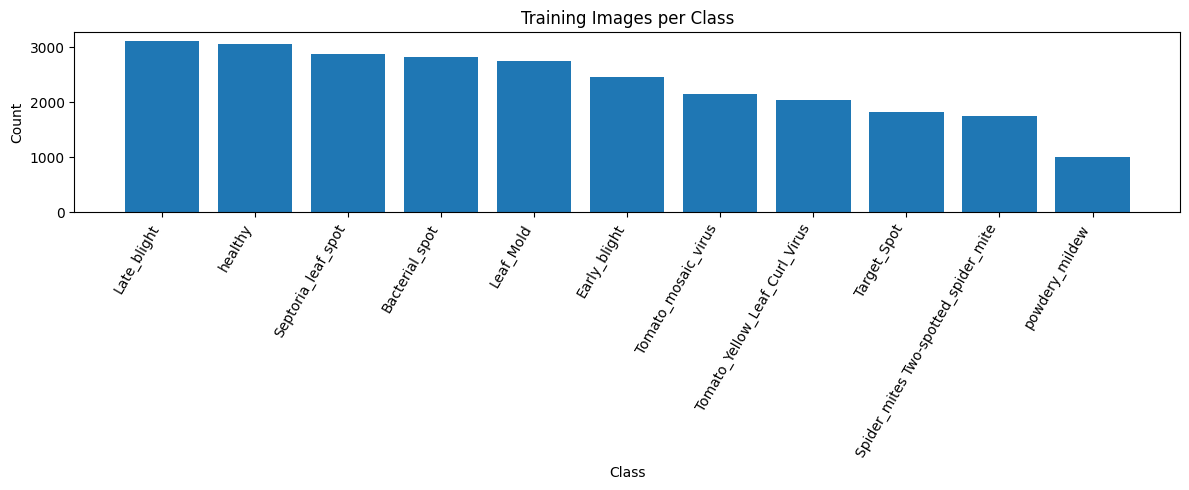

In [10]:
plt.figure(figsize=(12, 5))
plt.bar(class_counts_df["Class"], class_counts_df["Count"])
plt.xticks(rotation=60, ha="right")
plt.title("Training Images per Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Show sample images:

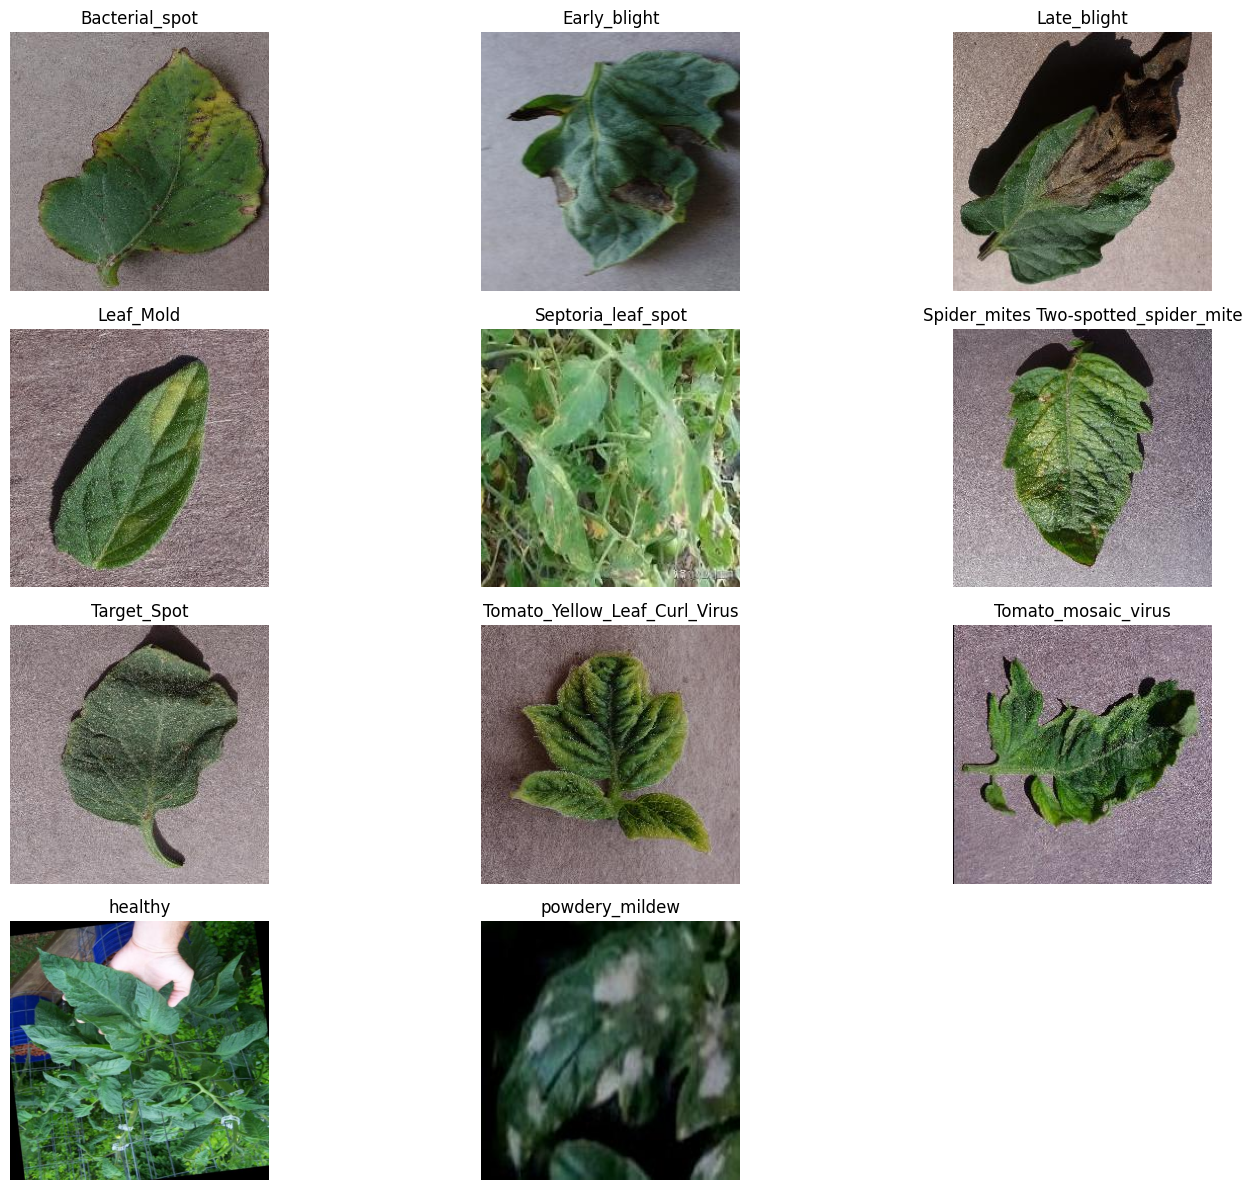

In [33]:
plt.figure(figsize=(15, 12))

for i, class_name in enumerate(class_names):
    class_folder = os.path.join(train_dir, class_name)
    image_name = os.listdir(class_folder)[0]
    image_path = os.path.join(class_folder, image_name)

    img = Image.open(image_path).convert("RGB")

    plt.subplot(4, 3, i + 1)   # adjust if needed
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

**7. Split the training folder into train and validation**

In [12]:
indices = list(range(len(train_base_dataset)))
labels = [train_base_dataset.samples[i][1] for i in indices]

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.20,
    stratify=labels,
    random_state=42
)

print("Train samples:", len(train_idx))
print("Validation samples:", len(val_idx))

Train samples: 20680
Validation samples: 5171


**8. Define preprocessing and augmentation**

In [13]:
img_size = 128
batch_size = 32

In [14]:
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

val_test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

**9. Create datasets and DataLoaders**

In [15]:
train_dataset = Subset(
    datasets.ImageFolder(train_dir, transform=train_transform),
    train_idx
)

val_dataset = Subset(
    datasets.ImageFolder(train_dir, transform=val_test_transform),
    val_idx
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=val_test_transform
)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 20680
Validation dataset size: 5171
Test dataset size: 6684


Check class order consistency:

In [16]:
test_class_names = test_dataset.classes
print("Train classes:", class_names)
print("Test classes :", test_class_names)

assert class_names == test_class_names, "Class order mismatch between train and test folders!"

Train classes: ['Bacterial_spot', 'Early_blight', 'Late_blight', 'Leaf_Mold', 'Septoria_leaf_spot', 'Spider_mites Two-spotted_spider_mite', 'Target_Spot', 'Tomato_Yellow_Leaf_Curl_Virus', 'Tomato_mosaic_virus', 'healthy', 'powdery_mildew']
Test classes : ['Bacterial_spot', 'Early_blight', 'Late_blight', 'Leaf_Mold', 'Septoria_leaf_spot', 'Spider_mites Two-spotted_spider_mite', 'Target_Spot', 'Tomato_Yellow_Leaf_Curl_Virus', 'Tomato_mosaic_virus', 'healthy', 'powdery_mildew']


Create loaders:

In [17]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 647
Validation batches: 162
Test batches: 209


**10. Define model 1: baseline custom CNN**

In [18]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d((4, 4))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

**11. Define model 2: with batch normalization and dropout**

In [19]:
class RegularizedCNN(nn.Module):
    def __init__(self, num_classes):
        super(RegularizedCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d((4, 4))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

**12. Show detailed model summary**

In [20]:
simple_model = SimpleCNN(num_classes).to(device)
regularized_model = RegularizedCNN(num_classes).to(device)

print("SimpleCNN Summary")
summary(simple_model, input_size=(batch_size, 3, img_size, img_size))

print("\nRegularizedCNN Summary")
summary(regularized_model, input_size=(batch_size, 3, img_size, img_size))

SimpleCNN Summary

RegularizedCNN Summary


Layer (type:depth-idx)                   Output Shape              Param #
RegularizedCNN                           [32, 11]                  --
├─Sequential: 1-1                        [32, 256, 8, 8]           --
│    └─Conv2d: 2-1                       [32, 32, 128, 128]        896
│    └─BatchNorm2d: 2-2                  [32, 32, 128, 128]        64
│    └─ReLU: 2-3                         [32, 32, 128, 128]        --
│    └─MaxPool2d: 2-4                    [32, 32, 64, 64]          --
│    └─Conv2d: 2-5                       [32, 64, 64, 64]          18,496
│    └─BatchNorm2d: 2-6                  [32, 64, 64, 64]          128
│    └─ReLU: 2-7                         [32, 64, 64, 64]          --
│    └─MaxPool2d: 2-8                    [32, 64, 32, 32]          --
│    └─Conv2d: 2-9                       [32, 128, 32, 32]         73,856
│    └─BatchNorm2d: 2-10                 [32, 128, 32, 32]         256
│    └─ReLU: 2-11                        [32, 128, 32, 32]         --
│   

**13. Define training and validation functions**

In [21]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

**14. Full training function with optimizer, scheduler, and cross-entropy loss**

In [22]:
def train_model(model, train_loader, val_loader, epochs=15, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | "
              f"LR: {current_lr:.6f}")

    model.load_state_dict(best_model_wts)
    return model, history

**15. Train both models**

In [23]:
epochs = 15

simple_model = SimpleCNN(num_classes).to(device)
regularized_model = RegularizedCNN(num_classes).to(device)

print("Training SimpleCNN...")
simple_model, simple_history = train_model(
    simple_model, train_loader, val_loader, epochs=epochs, lr=1e-3
)

print("\nTraining RegularizedCNN...")
regularized_model, regularized_history = train_model(
    regularized_model, train_loader, val_loader, epochs=epochs, lr=1e-3
)

Training SimpleCNN...
Epoch [1/15] | Train Loss: 1.5013, Train Acc: 0.4586 | Val Loss: 0.8936, Val Acc: 0.6871 | LR: 0.001000
Epoch [2/15] | Train Loss: 0.8299, Train Acc: 0.7135 | Val Loss: 0.6951, Val Acc: 0.7496 | LR: 0.001000
Epoch [3/15] | Train Loss: 0.6411, Train Acc: 0.7788 | Val Loss: 0.5366, Val Acc: 0.8122 | LR: 0.001000
Epoch [4/15] | Train Loss: 0.5401, Train Acc: 0.8087 | Val Loss: 0.5092, Val Acc: 0.8151 | LR: 0.001000
Epoch [5/15] | Train Loss: 0.4678, Train Acc: 0.8341 | Val Loss: 0.4220, Val Acc: 0.8536 | LR: 0.001000
Epoch [6/15] | Train Loss: 0.4167, Train Acc: 0.8540 | Val Loss: 0.3919, Val Acc: 0.8623 | LR: 0.001000
Epoch [7/15] | Train Loss: 0.3733, Train Acc: 0.8674 | Val Loss: 0.3586, Val Acc: 0.8803 | LR: 0.001000
Epoch [8/15] | Train Loss: 0.3470, Train Acc: 0.8805 | Val Loss: 0.3355, Val Acc: 0.8830 | LR: 0.001000
Epoch [9/15] | Train Loss: 0.3120, Train Acc: 0.8922 | Val Loss: 0.3245, Val Acc: 0.8919 | LR: 0.001000
Epoch [10/15] | Train Loss: 0.2899, Train 

**16. Plot training and validation curves**

In [24]:
def plot_history(history, title):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(10, 4))
    plt.plot(epochs_range, history["train_loss"], label="Train Loss")
    plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
    plt.title(f"{title} - Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs_range, history["val_acc"], label="Validation Accuracy")
    plt.title(f"{title} - Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

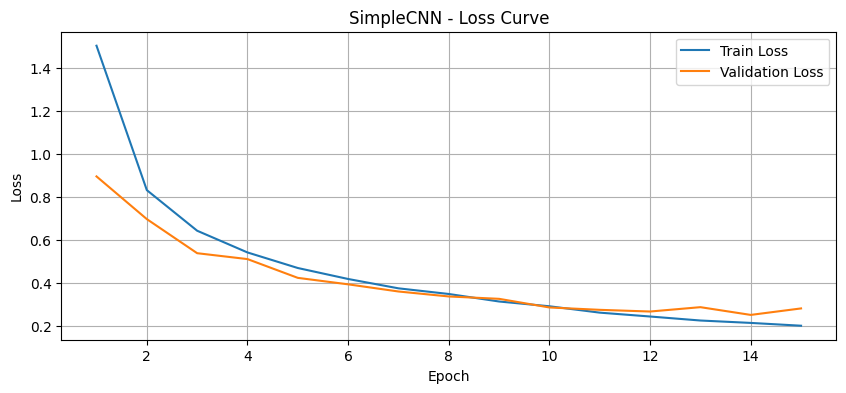

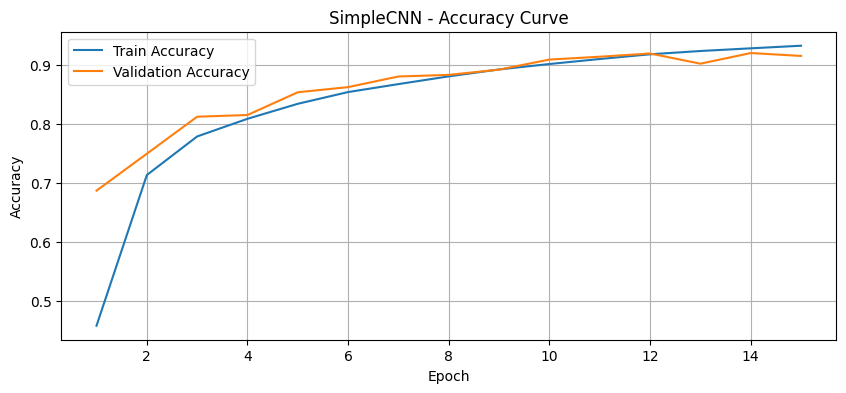

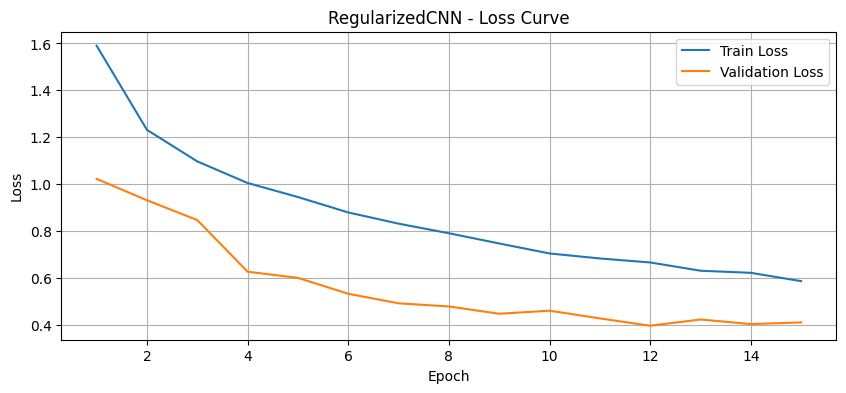

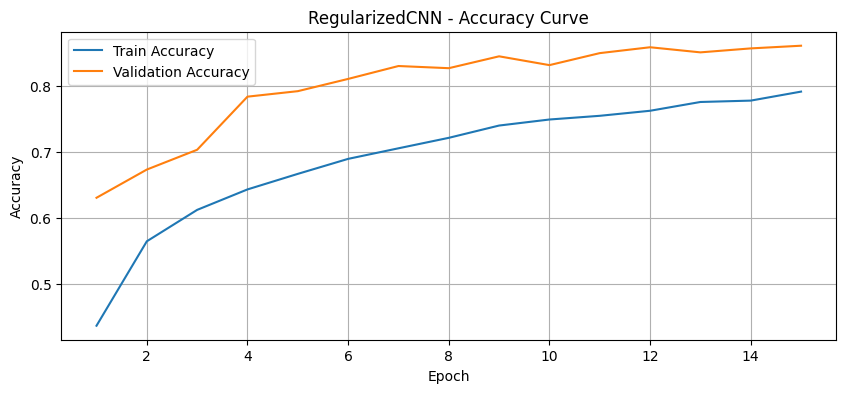

In [25]:
plot_history(simple_history, "SimpleCNN")
plot_history(regularized_history, "RegularizedCNN")

**17. Evaluate on test set**

In [27]:
def evaluate_model(model, loader, class_names):
    model.eval()
    y_true = []
    y_pred = []
    skipped_files = []

    dataset = loader.dataset

    # Handle both normal datasets and Subset datasets
    if isinstance(dataset, Subset):
        base_dataset = dataset.dataset
        indices = dataset.indices
    else:
        base_dataset = dataset
        indices = list(range(len(dataset)))

    with torch.no_grad():
        for idx in indices:
            path, label = base_dataset.samples[idx]
            try:
                img = Image.open(path).convert("RGB")

                if base_dataset.transform is not None:
                    img = base_dataset.transform(img)

                img = img.unsqueeze(0).to(device)
                outputs = model(img)
                _, pred = torch.max(outputs, 1)

                y_true.append(label)
                y_pred.append(pred.item())

            except Exception as e:
                skipped_files.append((path, str(e)))
                continue

    print(f"Total evaluated images: {len(y_true)}")
    print(f"Skipped broken images: {len(skipped_files)}")

    if len(skipped_files) > 0:
        print("\nFirst few skipped files:")
        for f, err in skipped_files[:5]:
            print(f"- {f} --> {err}")

    if len(y_true) == 0:
        print("No valid images were evaluated.")
        return None

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print("\nAccuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", xticks_rotation=90, values_format='d', ax=ax)
    plt.title("Confusion Matrix")
    plt.show()

    row_sums = cm.sum(axis=1)
    class_acc = np.divide(cm.diagonal(), row_sums, out=np.zeros_like(row_sums, dtype=float), where=row_sums != 0)

    class_perf_df = pd.DataFrame({
        "Class": class_names,
        "Class_Accuracy": class_acc
    }).sort_values("Class_Accuracy", ascending=False)

    print("\nPer-class Accuracy:")
    print(class_perf_df)

    best_class = class_perf_df.iloc[0]
    worst_class = class_perf_df.iloc[-1]

    print(f"\nBest Performing Class : {best_class['Class']} ({best_class['Class_Accuracy']:.4f})")
    print(f"Worst Performing Class: {worst_class['Class']} ({worst_class['Class_Accuracy']:.4f})")

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "class_perf_df": class_perf_df,
        "skipped_files": skipped_files
    }

SimpleCNN Test Results
Total evaluated images: 6684
Skipped broken images: 0

Accuracy : 0.9247
Precision: 0.9257
Recall   : 0.9247
F1-score : 0.9248

Classification Report:

                                      precision    recall  f1-score   support

                      Bacterial_spot       0.93      0.87      0.90       732
                        Early_blight       0.90      0.92      0.91       643
                         Late_blight       0.90      0.89      0.89       792
                           Leaf_Mold       0.93      0.92      0.93       739
                  Septoria_leaf_spot       0.84      0.91      0.87       746
Spider_mites Two-spotted_spider_mite       0.94      0.98      0.96       435
                         Target_Spot       0.96      0.92      0.94       457
       Tomato_Yellow_Leaf_Curl_Virus       0.96      0.97      0.97       498
                 Tomato_mosaic_virus       0.98      0.95      0.96       584
                             healthy       0

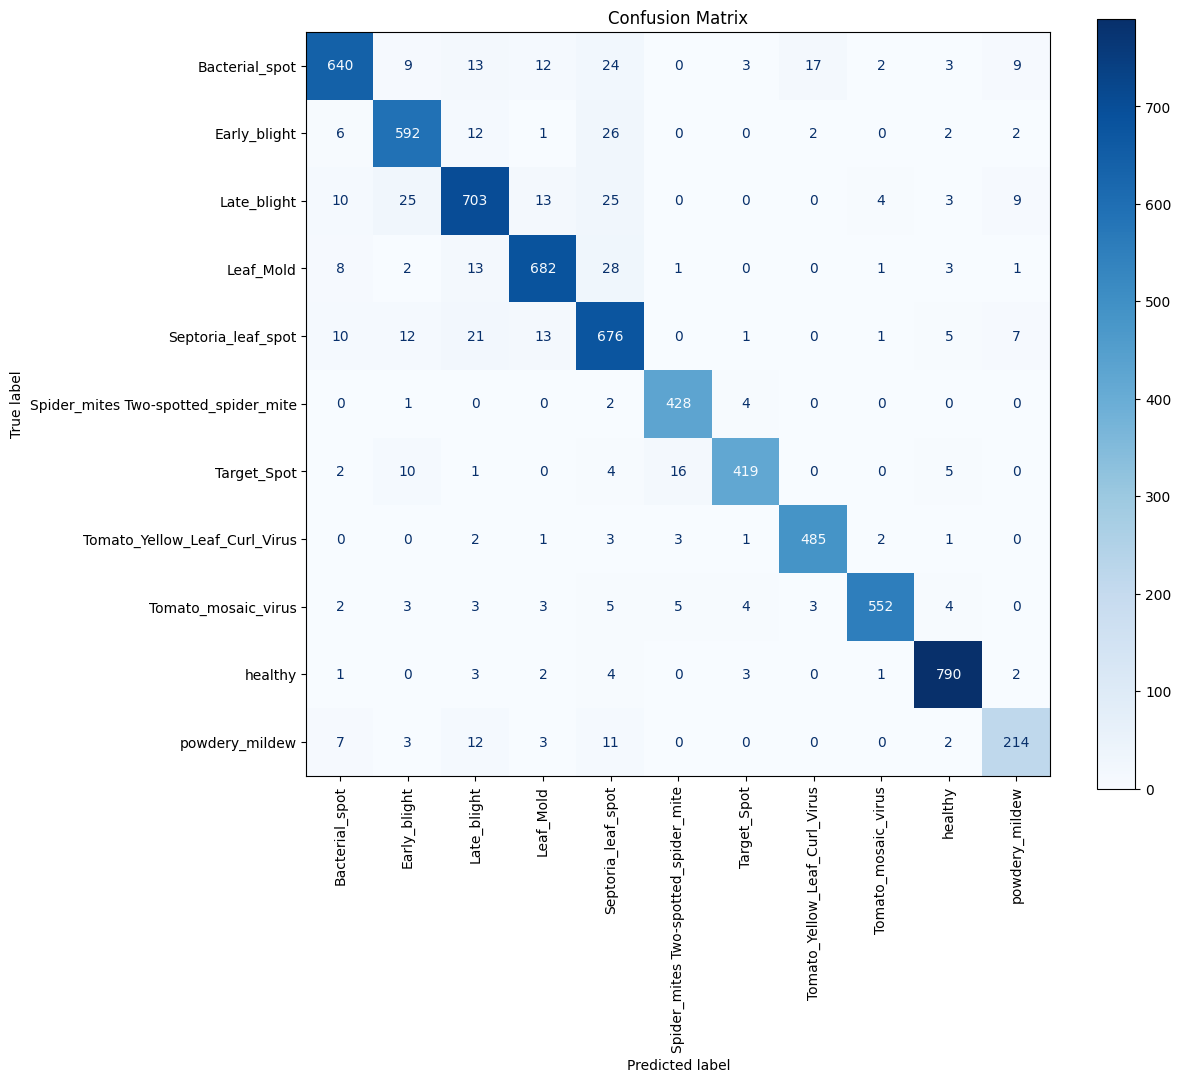


Per-class Accuracy:
                                   Class  Class_Accuracy
5   Spider_mites Two-spotted_spider_mite        0.983908
9                                healthy        0.980149
7          Tomato_Yellow_Leaf_Curl_Virus        0.973896
8                    Tomato_mosaic_virus        0.945205
3                              Leaf_Mold        0.922869
1                           Early_blight        0.920684
6                            Target_Spot        0.916849
4                     Septoria_leaf_spot        0.906166
2                            Late_blight        0.887626
0                         Bacterial_spot        0.874317
10                        powdery_mildew        0.849206

Best Performing Class : Spider_mites Two-spotted_spider_mite (0.9839)
Worst Performing Class: powdery_mildew (0.8492)


RegularizedCNN Test Results
Total evaluated images: 6684
Skipped broken images: 0

Accuracy : 0.8769
Precision: 0.8783
Recall   : 0.8769
F1-score : 0.8763

Classification Rep

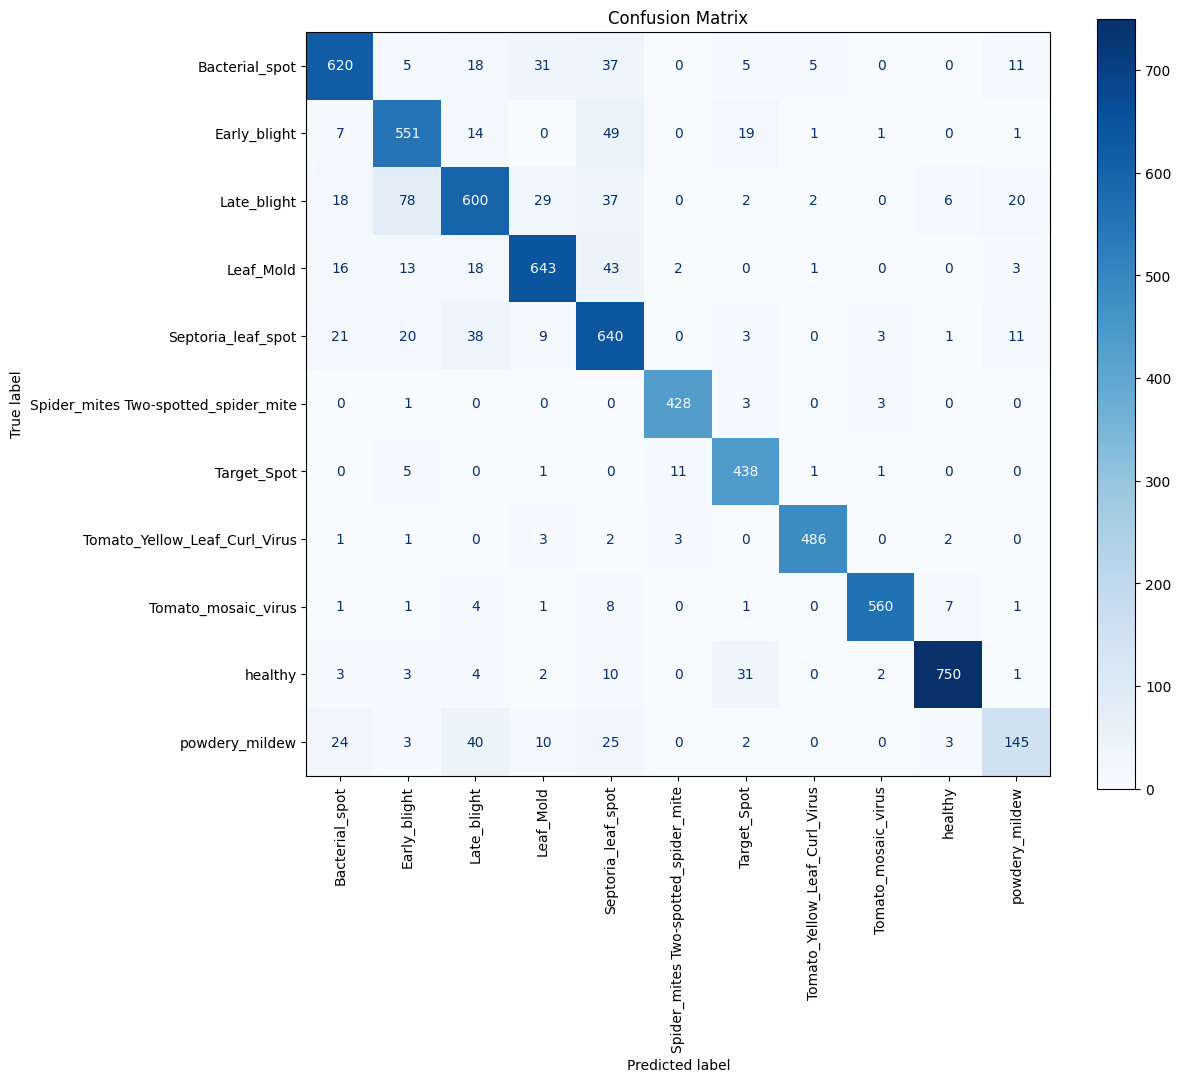


Per-class Accuracy:
                                   Class  Class_Accuracy
5   Spider_mites Two-spotted_spider_mite        0.983908
7          Tomato_Yellow_Leaf_Curl_Virus        0.975904
8                    Tomato_mosaic_virus        0.958904
6                            Target_Spot        0.958425
9                                healthy        0.930521
3                              Leaf_Mold        0.870095
4                     Septoria_leaf_spot        0.857909
1                           Early_blight        0.856921
0                         Bacterial_spot        0.846995
2                            Late_blight        0.757576
10                        powdery_mildew        0.575397

Best Performing Class : Spider_mites Two-spotted_spider_mite (0.9839)
Worst Performing Class: powdery_mildew (0.5754)


In [28]:
print("SimpleCNN Test Results")
simple_results = evaluate_model(simple_model, test_loader, class_names)

print("\n" + "="*80 + "\n")

print("RegularizedCNN Test Results")
regularized_results = evaluate_model(regularized_model, test_loader, class_names)

**18. Compare both models**

In [29]:
comparison_df = pd.DataFrame([
    {
        "Model": "SimpleCNN",
        "Accuracy": simple_results["accuracy"],
        "Precision": simple_results["precision"],
        "Recall": simple_results["recall"],
        "F1-score": simple_results["f1"]
    },
    {
        "Model": "RegularizedCNN",
        "Accuracy": regularized_results["accuracy"],
        "Precision": regularized_results["precision"],
        "Recall": regularized_results["recall"],
        "F1-score": regularized_results["f1"]
    }
])

comparison_df

,Model,Accuracy,Precision,Recall,F1-score
0,SimpleCNN,0.924746,0.925720,0.924746,0.924842
1,RegularizedCNN,0.876870,0.878318,0.876870,0.876318


Pick the better model:

In [30]:
best_model_name = comparison_df.sort_values("Accuracy", ascending=False).iloc[0]["Model"]
print("Best model based on test accuracy:", best_model_name)

Best model based on test accuracy: SimpleCNN


**19. Save trained model weights**

In [31]:
torch.save(simple_model.state_dict(), "simple_cnn_tomato.pth")
torch.save(regularized_model.state_dict(), "regularized_cnn_tomato.pth")

print("Model weights saved successfully.")

Model weights saved successfully.


In [32]:
from google.colab import files
files.download("simple_cnn_tomato.pth")
files.download("regularized_cnn_tomato.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Hyperparameter Details and Rationale

- **Image size = 128 × 128**  
  This size was chosen to reduce training time and memory usage while still preserving important visual patterns of tomato leaf diseases.

- **Batch size = 32**  
  A batch size of 32 provides a good balance between stable gradient updates and computational efficiency.

- **Epochs = 15**  
  Fifteen epochs were selected as a reasonable setting for comparing the two CNN architectures within the scope of this assignment.

- **Optimizer = Adam**  
  Adam was chosen because it usually converges faster and requires less manual tuning than standard SGD.

- **Loss function = CrossEntropyLoss**  
  This loss function is appropriate for multi-class image classification tasks.

- **Learning-rate scheduler = ReduceLROnPlateau**  
  This scheduler reduces the learning rate automatically when the validation loss stops improving, which helps training converge more effectively.

- **Dropout = 0.5**  
  A dropout rate of 0.5 was used in the regularized CNN to reduce overfitting by randomly deactivating neurons during training.

- **Batch Normalization**  
  Batch normalization was added to improve training stability, accelerate convergence, and support better generalization.

## Analysis and Discussion

Two custom CNN models were trained for tomato leaf disease classification: a baseline SimpleCNN and a RegularizedCNN with Batch Normalization and Dropout. Data augmentation was applied to the training set to improve generalization.

Based on the test results, the SimpleCNN performed better than the RegularizedCNN. The SimpleCNN achieved a test accuracy of 0.9247, weighted precision of 0.9257, weighted recall of 0.9247, and weighted F1-score of 0.9248. In comparison, the RegularizedCNN achieved a test accuracy of 0.8769 and weighted F1-score of 0.8763.

The confusion matrix and per-class analysis showed that Spider_mites Two-spotted_spider_mite and healthy were among the best-performing classes, while powdery_mildew was the most difficult class to classify. This suggests that some disease categories have more visually distinctive features than others.

Overall, the baseline SimpleCNN generalized better on this dataset than the regularized version. Future work could explore deeper CNNs, transfer learning, longer training, or class-specific balancing techniques.

## Conclusion

In this project, a custom CNN was developed for multi-class tomato leaf disease classification. Two architectures were compared: a baseline SimpleCNN and a RegularizedCNN with Batch Normalization and Dropout. The results showed that both models were effective, but the SimpleCNN achieved the best overall performance on the test set. This project demonstrates a complete deep learning workflow including data preprocessing, model design, training, evaluation, visualization, and model saving.